In [ ]:
import networkx as nx
import matplotlib.pyplot as plt
import pandas as pd
import numpy as np


from pyvis.network import Network



pd.set_option('display.max_columns', None)
pd.set_option('display.max_rows', None)

# load dataset with pac and vendor connections
pac_vendor_agg = pd.read_csv('../data/processed/pac_vendor_agg.csv')


pac_vendor_agg.head()

,filer_committee_id_number,test_vendor,exp_cat,ttl_spend,n_transactions,committee_designation,committee_designation_full,committee_id,committee_name,committee_state,committee_type,committee_type_full,coverage_end_date,coverage_start_date,cycle,disbursements,filing_frequency,first_file_date,individual_contributions,individual_itemized_contributions,individual_unitemized_contributions,organization_type,organization_type_full,receipts,treasurer_name
0,C00000059,BLAKE MOORE FOR CONGRESS,OTHER,1000.0,1,B,Lobbyist/Registrant PAC,C00000059,"HALLMARK CARDS, INC. PAC (HALLPAC)",MO,Q,PAC - Qualified,2024-12-31T00:00:00,2023-01-01T00:00:00,2024.0,117500.0,M,1976-04-22,91727.18,62548.68,29178.5,C,Corporation,95727.18,"KLEIN, CASSIE MS."
1,C00000059,BOB CASEY FOR SENATE,OTHER,2500.0,1,B,Lobbyist/Registrant PAC,C00000059,"HALLMARK CARDS, INC. PAC (HALLPAC)",MO,Q,PAC - Qualified,2024-12-31T00:00:00,2023-01-01T00:00:00,2024.0,117500.0,M,1976-04-22,91727.18,62548.68,29178.5,C,Corporation,95727.18,"KLEIN, CASSIE MS."
2,C00000059,BOOZMAN FOR AR,OTHER,2500.0,1,B,Lobbyist/Registrant PAC,C00000059,"HALLMARK CARDS, INC. PAC (HALLPAC)",MO,Q,PAC - Qualified,2024-12-31T00:00:00,2023-01-01T00:00:00,2024.0,117500.0,M,1976-04-22,91727.18,62548.68,29178.5,C,Corporation,95727.18,"KLEIN, CASSIE MS."
3,C00000059,BRIAN FITZPATRICK FOR CONGRESS,OTHER,2500.0,1,B,Lobbyist/Registrant PAC,C00000059,"HALLMARK CARDS, INC. PAC (HALLPAC)",MO,Q,PAC - Qualified,2024-12-31T00:00:00,2023-01-01T00:00:00,2024.0,117500.0,M,1976-04-22,91727.18,62548.68,29178.5,C,Corporation,95727.18,"KLEIN, CASSIE MS."
4,C00000059,CANTWELL VICTORY,OTHER,2500.0,1,B,Lobbyist/Registrant PAC,C00000059,"HALLMARK CARDS, INC. PAC (HALLPAC)",MO,Q,PAC - Qualified,2024-12-31T00:00:00,2023-01-01T00:00:00,2024.0,117500.0,M,1976-04-22,91727.18,62548.68,29178.5,C,Corporation,95727.18,"KLEIN, CASSIE MS."


In [27]:
# Define calculated columns 

# pct_indiv: the percent of a PACs receipts that come from individuals
pac_vendor_agg['pct_indiv'] = pac_vendor_agg['individual_contributions']/pac_vendor_agg['receipts']

# pct_unitem: the percent of a PACs receipts that come from unitemized individuals
pac_vendor_agg['pct_unitem'] = pac_vendor_agg['individual_unitemized_contributions']/pac_vendor_agg['receipts']

# n_unique_filers: the number of filers that paid a given vendor
pac_vendor_agg['n_unique_filers'] = (
    pac_vendor_agg.groupby('test_vendor')['filer_committee_id_number']
    .transform('nunique')
)

# n_unique_vendors: the number of vendors that a given filer used 
pac_vendor_agg['n_unique_vendors'] = (
    pac_vendor_agg.groupby('filer_committee_id_number')['test_vendor']
    .transform('nunique')
)



pac_vendor_agg['is_union_pac'] = np.where(pac_vendor_agg.committee_name.str.contains('FEDERATION|UNION|LOCAL (?:#|NO\.)?\s?\d+|ASSOC.?\w+? OF|SEIU|IBEW|UAW|TEAMSTERS|BROTHERHOOD OF|UNITED \w+ WORKERS OF|AFSCME|VOLUNTARY POLITICAL COMMITTEE',regex=True),True, False)

<>:23: SyntaxWarning: invalid escape sequence '\.'
<>:23: SyntaxWarning: invalid escape sequence '\.'
/var/folders/cl/bdrh3m8j0fdfj6zm7zhhc2ch0000gn/T/ipykernel_38158/2459282847.py:23: SyntaxWarning: invalid escape sequence '\.'
  pac_vendor_agg['is_union_pac'] = np.where(pac_vendor_agg.committee_name.str.contains('FEDERATION|UNION|LOCAL (?:#|NO\.)?\s?\d+|ASSOC.?\w+? OF|SEIU|IBEW|UAW|TEAMSTERS|BROTHERHOOD OF|UNITED \w+ WORKERS OF|AFSCME|VOLUNTARY POLITICAL COMMITTEE',regex=True),True, False)


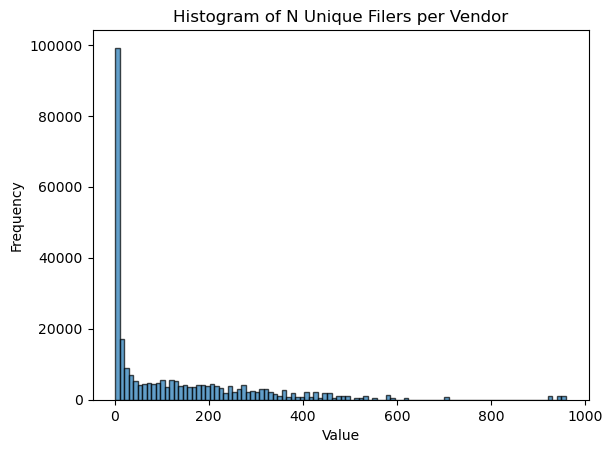

In [28]:
# Plot the distribution of N Unique Filers 
plt.hist(pac_vendor_agg['n_unique_filers'], bins = 100, edgecolor='black', alpha=0.7)

# 3. Add labels and a title for clarity
plt.xlabel("Value")
plt.ylabel("Frequency")
plt.title("Histogram of N Unique Filers per Vendor")

# 4. Display the plot
plt.show()

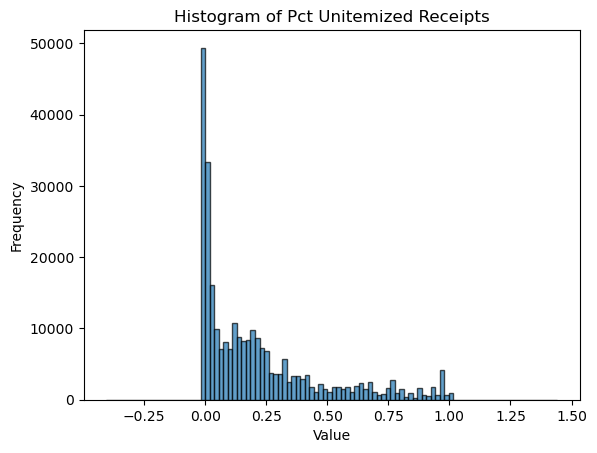

In [ ]:
# Plot the districution of pct unitem 
plt.hist(pac_vendor_agg['pct_unitem'], bins = 100, edgecolor='black', alpha=0.7)

# 3. Add labels and a title for clarity
plt.xlabel("Value")
plt.ylabel("Frequency")
plt.title("Histogram of Pct Unitemized Receipts")

# 4. Display the plot
plt.show()

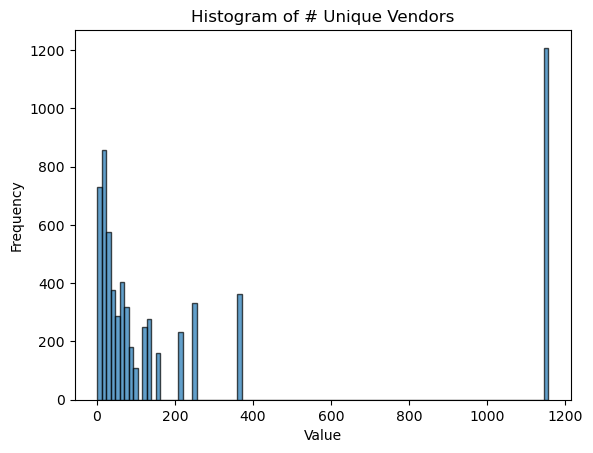

In [ ]:
# Plot the distribution of N unique vendors 
plt.hist(df['n_unique_vendors'], bins = 100, edgecolor='black', alpha=0.7)

# 3. Add labels and a title for clarity
plt.xlabel("Value")
plt.ylabel("Frequency")
plt.title("Histogram of # Unique Vendors")

# 4. Display the plot
plt.show()

In [115]:
df[df['n_unique_vendors']>100].committee_name.unique()

array(['SEAFARERS POLITICAL ACTIVITY DONATION - SEAFARERS INTERNATIONAL UNION OF NA-AGLIW',
       'AMERICAN POSTAL WORKERS UNION COMMITTEE ON POLITICAL ACTION',
       'UNITED MINE WORKERS OF AMERICA - COAL MINERS POLITICAL ACTION COMMITTEE',
       'VOICE OF TEACHERS FOR EDUC/CMTE ON POL EDUC OF NY STATE UNTD TEACHERS (VOTE/COPE) OF NYSUT',
       'AMERICAN FEDERATION OF TEACHERS, AFL-CIO COMMITTEE ON POLITICAL EDUCATION',
       'D.R.I.V.E. - DEMOCRAT, REPUBLICAN, INDEPENDENT VOTER EDUCATION (THE PAC OF THE INTERNATIONAL BROTHERHOOD OF TEAMSTERS)',
       'PIPEFITTERS LOCAL #533 VOLUNTEER POLITICAL FUND',
       'WESTERN STATES REGIONAL COUNCIL OF CARPENTERS LEGISLATIVE IMPROVEMENT CMTE UNITED BROTHERHOOD OF CARPENTERS & JOINERS OF AMERICA',
       'NATIONAL PRO-LIFE ALLIANCE PAC',
       "MID-ATLANTIC LABORERS' POLITICAL LEAGUE/LABORERS' INTERNATIONAL UNION OF NORTH AMERICA"],
      dtype=object)

In [94]:
len(pac_vendor_agg[pac_vendor_agg['pct_unitem']>.90].committee_name.unique())

262

In [97]:
pac_vendor_agg[pac_vendor_agg['n_unique_filers']>100].test_vendor.unique()

array(['BLAKE MOORE FOR CONGRESS', 'BOB CASEY FOR SENATE',
       'BOOZMAN FOR AR', 'CANTWELL VICTORY', 'CARTWRIGHT FOR CONGRESS',
       'CLARKE FOR CONGRESS', 'CLEAVER FOR CONGRESS',
       'COMER FOR CONGRESS', 'CONNOLLY FOR CONGRESS',
       'DEBBIE DINGELL FOR CONGRESS', 'ERIC BURLISON FOR CONGRESS',
       'FRIENDS OF DAVE JOYCE', 'FRIENDS OF RAJA FOR CONGRESS',
       'GRAVES FOR CONGRESS', 'JAMIE RASKIN FOR CONGRESS', 'JOHN CURTIS',
       'MAD  PA', 'MANN FOR CONGRESS', 'MARK ALFORD FOR CONGRESS',
       'PETERS FOR MI', 'RON ESTES FOR CONGRESS', 'SHARICE FOR CONGRESS',
       'SMUCKER FOR CONGRESS', 'TAMMY BALDWIN', 'WINNING FOR AMERICA',
       'WOMACK FOR CONGRESS COMMITTEE', 'ADRIAN SMITH FOR CONGRESS',
       'AGUILAR PETE', 'ALAMO', 'ALMA ADAMS FOR CONGRESS',
       'AMERICA REVIVAL', 'ANDRE CARSON FOR CONGRESS', 'ANDREA SALINAS',
       'ANDY BARR FOR CONGRESS', 'ANGIE CRAIG', 'ANNA ESHOO FOR CONGRESS',
       'AR FOR LEADERSHIP POLITICAL ACTION COMMITTEE ARKPAC',
     

In [99]:
len(pac_vendor_agg[pac_vendor_agg['pct_indiv']>=.75].committee_name.unique())

4456

In [30]:
# ---- STEP 1: Build the base graph ----
G = nx.Graph()

# Optional: reduce to significant edges only (recommended)
# e.g., keep only vendors with >= 10 transactions
df = pac_vendor_agg.copy()
df = df[(df['pct_unitem']>.75) & (df['receipts']>=25000) & ~(df['committee_designation_full']=='Lobbyist/Registrant PAC') & ~(df['is_union_pac']==True)]

In [4]:
# ---- STEP 1: Build the base graph ----
G = nx.Graph()

# Optional: reduce to significant edges only (recommended)
# e.g., keep only vendors with >= 10 transactions
df = pac_vendor_agg.copy()
df = df[(df['pct_unitem']>.75) & (df['receipts']>=25000) & ~(df['committee_designation_full']=='Lobbyist/Registrant PAC')]

# ---- STEP 2: Add nodes (with color groups) ----
filers = df['committee_name'].unique()
vendors = df['test_vendor'].unique()

G.add_nodes_from(filers, bipartite='filer', color='blue')
G.add_nodes_from(test_vendors, bipartite='test_vendor', color='orange')

# ---- STEP 3: Add edges ----
edges = list(zip(df['committee_name'], df['test_vendor']))
G.add_edges_from(edges)

# ---- STEP 5: Styling for readability ----

net = Network(height='900px', width='100%', bgcolor='white', font_color='black', notebook=False)

net.from_nx(G)

# shrink node sizes for large networks
for node in net.nodes:
    if node['color'] == 'blue':   # filers
        node['size'] = 8
    else:                          # vendors
        node['size'] = 6

# shrink edge thickness
for edge in net.edges:
    edge['width'] = 0.5
# Improve readability:
net.barnes_hut()                           # physics layout
net.force_atlas_2based() 
net.save_graph('filer_vendor_network.html')





NameError: name 'test_vendors' is not defined

In [ ]:
pac_vendor_agg[pac_vendor_agg['committee_name']=='DEMOCRATIC VOTERS PAC'].sort_values('ttl_spend',ascending = False)

# THE MAJORITY RULES 
# STOP MAGA PAC
# DEMOCRATS UNITED
# RETIRED DEMS 2024
# ABLE DEMS PAC
# CRUSH MAGA PAC
# DEMOCRATIC VOTERS PAC

,filer_committee_id_number,vendor,ttl_spend,n_transactions,committee_designation,committee_designation_full,committee_id,committee_name,committee_state,committee_type,committee_type_full,coverage_end_date,coverage_start_date,cycle,disbursements,filing_frequency,first_file_date,individual_contributions,individual_itemized_contributions,individual_unitemized_contributions,organization_type,organization_type_full,receipts,treasurer_name,pct_indiv,pct_unitem,n_unique_filers,n_unique_vendors
65466,C00816868,PACTION DATA,2252846.27,14,U,Unauthorized,C00816868,DEMOCRATIC VOTERS PAC,DC,N,PAC - Nonqualified,2024-12-31T00:00:00,2023-01-01T00:00:00,2024.0,7271088.05,Q,2022-06-01,7168861.75,1318613.36,5850248.39,NaN,NaN,7168886.75,"HAGGARD, LORA",0.999997,0.816061,17,11
65464,C00816868,DLCC,450000.00,1,U,Unauthorized,C00816868,DEMOCRATIC VOTERS PAC,DC,N,PAC - Nonqualified,2024-12-31T00:00:00,2023-01-01T00:00:00,2024.0,7271088.05,Q,2022-06-01,7168861.75,1318613.36,5850248.39,NaN,NaN,7168886.75,"HAGGARD, LORA",0.999997,0.816061,56,11
65462,C00816868,ActBlue,277314.71,79,U,Unauthorized,C00816868,DEMOCRATIC VOTERS PAC,DC,N,PAC - Nonqualified,2024-12-31T00:00:00,2023-01-01T00:00:00,2024.0,7271088.05,Q,2022-06-01,7168861.75,1318613.36,5850248.39,NaN,NaN,7168886.75,"HAGGARD, LORA",0.999997,0.816061,959,11
65470,C00816868,UAW,170000.00,2,U,Unauthorized,C00816868,DEMOCRATIC VOTERS PAC,DC,N,PAC - Nonqualified,2024-12-31T00:00:00,2023-01-01T00:00:00,2024.0,7271088.05,Q,2022-06-01,7168861.75,1318613.36,5850248.39,NaN,NaN,7168886.75,"HAGGARD, LORA",0.999997,0.816061,941,11
65471,C00816868,VOTEVETS,100000.00,2,U,Unauthorized,C00816868,DEMOCRATIC VOTERS PAC,DC,N,PAC - Nonqualified,2024-12-31T00:00:00,2023-01-01T00:00:00,2024.0,7271088.05,Q,2022-06-01,7168861.75,1318613.36,5850248.39,NaN,NaN,7168886.75,"HAGGARD, LORA",0.999997,0.816061,66,11
65463,C00816868,DEMOCRATIC LIEUTENANT GOVERNORS ASSOCIATION,60000.00,1,U,Unauthorized,C00816868,DEMOCRATIC VOTERS PAC,DC,N,PAC - Nonqualified,2024-12-31T00:00:00,2023-01-01T00:00:00,2024.0,7271088.05,Q,2022-06-01,7168861.75,1318613.36,5850248.39,NaN,NaN,7168886.75,"HAGGARD, LORA",0.999997,0.816061,19,11
65465,C00816868,NGPVAN,20304.30,21,U,Unauthorized,C00816868,DEMOCRATIC VOTERS PAC,DC,N,PAC - Nonqualified,2024-12-31T00:00:00,2023-01-01T00:00:00,2024.0,7271088.05,Q,2022-06-01,7168861.75,1318613.36,5850248.39,NaN,NaN,7168886.75,"HAGGARD, LORA",0.999997,0.816061,705,11
65467,C00816868,PLANNED PARENTHOOD,5000.00,1,U,Unauthorized,C00816868,DEMOCRATIC VOTERS PAC,DC,N,PAC - Nonqualified,2024-12-31T00:00:00,2023-01-01T00:00:00,2024.0,7271088.05,Q,2022-06-01,7168861.75,1318613.36,5850248.39,NaN,NaN,7168886.75,"HAGGARD, LORA",0.999997,0.816061,48,11
65468,C00816868,SAPPHIRE STRATEGIES,2903.00,1,U,Unauthorized,C00816868,DEMOCRATIC VOTERS PAC,DC,N,PAC - Nonqualified,2024-12-31T00:00:00,2023-01-01T00:00:00,2024.0,7271088.05,Q,2022-06-01,7168861.75,1318613.36,5850248.39,NaN,NaN,7168886.75,"HAGGARD, LORA",0.999997,0.816061,15,11
65461,C00816868,AMALGAMATED BANK,1783.70,18,U,Unauthorized,C00816868,DEMOCRATIC VOTERS PAC,DC,N,PAC - Nonqualified,2024-12-31T00:00:00,2023-01-01T00:00:00,2024.0,7271088.05,Q,2022-06-01,7168861.75,1318613.36,5850248.39,NaN,NaN,7168886.75,"HAGGARD, LORA",0.999997,0.816061,619,11


In [ ]:
df[(df['pct_unitem']>.35) & (df['receipts']>=25000)].filter(['filer_committee_id_number','committee_name','committee_designation_full','committee_type_full','n_unique_vendors'], axis = 1).drop_duplicates()

In [101]:
df['exp_cat'].unique()

array(['CONTRIBUTION', 'REFUND', 'OTHER', 'OVERHEAD', 'CONSULTING',
       'SALARY AND BENEFITS', 'TECHNOLOGY', 'TRAVEL', 'FUNDRAISING',
       'BANK FEES', 'TAXES', 'POLLING', 'CREDIT CARD PAYMENT',
       'ADVERTISEMENTS', 'EVENTS', 'SMS, PHONEBANKING, DIGITAL FIELD',
       'EARMARK'], dtype=object)

In [31]:
# ---- STEP 0: Category Color Dictionary (custom palette) ----
category_colors = {
    "CONTRIBUTION":          "#8C564B",
    "REFUND":                "#BCBD22",
    "OTHER":                 "#7F7F7F",
    "OVERHEAD":              "#C49C94",
    "CONSULTING":            "#9467BD",
    "SALARY AND BENEFITS":   "#D7B5A6",
    "TECHNOLOGY":            "#17BECF",
    "TRAVEL":                "#FFBB78",
    "FUNDRAISING":           "#2CA02C",  # GREEN
    "BANK FEES":             "#E2BFDF",
    "TAXES":                 "#E7BA52",
    "POLLUING":              "#A6A98F",
    "CREDIT CARD PAYMENT":   "#A1CFCF",
    "ADVERTISEMENTS":        "#FF7F0E",
    "EVENTS":                "#C5B0D5",
    "SMS, PHONEBANKING, DIGITAL FIELD": "#9EDAE5",
    "EARMARK":               "#A57C65",
}

default_vendor_color = "#999999"  # fallback gray
filer_color = "#000000"           # black


# ---- STEP 1: Filter your dataset ----
df = pac_vendor_agg.copy()

df = df[
    (df['pct_unitem'] > .75) & 
    (df['receipts'] >= 25000) &
    (df['n_unique_vendors']<100) &
    ~(df['committee_designation_full'] == 'Lobbyist/Registrant PAC')
]

# Ensure no missing category
df['exp_cat'] = df['exp_cat'].fillna("OTHER")


# ---- STEP 2: Build Graph ----
G = nx.Graph()

filers = df['committee_name'].unique()
vendors = df['test_vendor'].unique()

# Add filer nodes
for f in filers:
    G.add_node(f, node_type="filer", color=filer_color)

# Add vendor nodes with category-based color
for _, row in df[['test_vendor', 'exp_cat']].drop_duplicates().iterrows():
    vendor = row['test_vendor']
    cat = row['exp_cat']
    color = category_colors.get(cat, default_vendor_color)
    G.add_node(vendor, node_type="vendor", color=color)

# Add edges
for _, row in df[['committee_name', 'test_vendor']].drop_duplicates().iterrows():
    G.add_edge(row['committee_name'], row['test_vendor'])


# ---- STEP 3: Convert to PyVis ----
net = Network(
    height='900px',
    width='100%',
    bgcolor='white',
    font_color='black',
    notebook=False
)

net.from_nx(G)


# ---- STEP 4: Node Styling (sizes, colors already set) ----

for node in net.nodes:
    if node['color'] == filer_color:
        node['size'] = 10
        node['shape'] = "dot"
    else:
        node['size'] = 6
        node['shape'] = "dot"

# Thin edges
for edge in net.edges:
    edge['width'] = 0.5


# ---- STEP 5: Improve layout (physics) ----
net.barnes_hut()
net.force_atlas_2based()


# ---- STEP 6: Save ----
net.save_graph('filer_vendor_network.html')
print("Network graph saved as filer_vendor_network.html")


Network graph saved as filer_vendor_network.html


In [ ]:
# GOD FAMILY AND COUNTRY
#TEA PARTY EXPRESS .ORG
# USA FREEDOM FUND
#the american dream pac
#Verterans Aid pac
#upright pac
#democratic defense fund
#november coalition
#republicans are corrupt action fund
#defund apartheid action
#defeat the extreme fund
# united womens health alliance pac 

In [ ]:

df.sort_values('n_unique_vendors', ascending = False).filter(['committee_name','n_unique_vendors']).drop_duplicates()


,committee_name,n_unique_vendors
29158,"D.R.I.V.E. - DEMOCRAT, REPUBLICAN, INDEPENDENT...",1156
26312,"AMERICAN FEDERATION OF TEACHERS, AFL-CIO COMMI...",360
14970,AMERICAN POSTAL WORKERS UNION COMMITTEE ON POL...,252
18570,UNITED MINE WORKERS OF AMERICA - COAL MINERS P...,209
114032,WESTERN STATES REGIONAL COUNCIL OF CARPENTERS ...,156
130557,NATIONAL PRO-LIFE ALLIANCE PAC,133
20841,VOICE OF TEACHERS FOR EDUC/CMTE ON POL EDUC OF...,131
156950,MID-ATLANTIC LABORERS' POLITICAL LEAGUE/LABORE...,125
91649,PIPEFITTERS LOCAL #533 VOLUNTEER POLITICAL FUND,121
9355,SEAFARERS POLITICAL ACTIVITY DONATION - SEAFAR...,103


In [32]:
pac_vendor_agg.columns

Index(['filer_committee_id_number', 'test_vendor', 'exp_cat', 'ttl_spend',
       'n_transactions', 'committee_designation', 'committee_designation_full',
       'committee_id', 'committee_name', 'committee_state', 'committee_type',
       'committee_type_full', 'coverage_end_date', 'coverage_start_date',
       'cycle', 'disbursements', 'filing_frequency', 'first_file_date',
       'individual_contributions', 'individual_itemized_contributions',
       'individual_unitemized_contributions', 'organization_type',
       'organization_type_full', 'receipts', 'treasurer_name', 'pct_indiv',
       'pct_unitem', 'n_unique_filers', 'n_unique_vendors', 'is_union_pac'],
      dtype='object')

In [25]:
df[df['is_union_pac']==False].committee_name.unique()

array(['NORTH CAROLINA DENTAL SOCIETY PAC',
       'VOICE OF TEACHERS FOR EDUC/CMTE ON POL EDUC OF NY STATE UNTD TEACHERS (VOTE/COPE) OF NYSUT',
       'FLOWERS FOODS, INC. POLITICAL ACTION COMMITTEE',
       'AMERICAN MOTORCYCLIST ASSOCIATION  POLITICAL ACTION COMMITTEE',
       'ELECTROPAC',
       'COOPERATIVE OF AMERICAN PHYSICIANS FEDERAL POLITICAL ACTION COMMITTEE',
       "SUFFOLK COUNTY PATROLMEN'S BENEVOLENT ASSOCIATION FEDERAL PAC (SCPBA FEDERAL PAC)",
       'CALIFORNIA STATE PIPE TRADES COUNCIL VOLUNTARY POLITICAL ACTION FUND',
       'MILWAUKEE POLICE ASSOCIATION PAC',
       'ACADIAN AMBULANCE  SERVICE EMPLOYEE FEDERAL POLITICAL ACTION COMMITTEE, INC.',
       'ASSOCIATED HIGHWAY PATROLMEN OF ARIZONA',
       'LOUISIANA SHERIFFS AND DEPUTIES POLITICAL ACTION COMMITTEE',
       'NATIONAL PRO-LIFE ALLIANCE PAC',
       "DAVID VOLKERT & ASSOCIATES, INC. POLITICAL ACTION COMMITTEE ('DVA/HC PAC')",
       'UTAH BANKERS ASSOCIATION ACTION PAC',
       'DEMOCRATIC CLUB OF CLAREM